# COVID-19 Deaths Forecasting — JHU CSSE Format

**Data format:** JHU CSSE `time_series_covid19_deaths_US.csv`  
- Header row present  
- Location hierarchy: `Country_Region` → `Province_State` → `Admin2` (cols 6, 7, 8 / 0-indexed)  
- Time series starts at column index 12, column name `1/22/20`  
- Daily cumulative death counts (we'll convert to daily deltas)  
**Forecast:** 90 days ahead using a 2-layer LSTM wrapped in a HuggingFace-style Pipeline

## 1. Installs

In [1]:
!pip install -q transformers torch numpy pandas matplotlib scikit-learn

## 2. Imports & Config

In [7]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.preprocessing import MinMaxScaler
from transformers import Pipeline
import pickle
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | device: {device}')

# ── Column indices (0-based) ──────────────────────────────────────────────────
COL_ADMIN2         = 5    # county
COL_PROVINCE_STATE = 6    # state
COL_COUNTRY_REGION = 7    # country
COL_SERIES_START   = 12   # first date column ("1/22/20")

# ── Model config ──────────────────────────────────────────────────────────────
SEQ_LEN      = 60    # look-back window (days)
FORECAST_LEN = 90    # days ahead to predict
BATCH_SIZE   = 32
EPOCHS       = 50
LR           = 1e-3

PyTorch 2.10.0+cpu | device: cpu


## 3. Load & Parse the JHU CSV

**Set `DATA_FILE` to your uploaded filename below.**

In [5]:
DATA_FILE = 'time_series_covid19_deaths_US.csv'   # <-- set your filename here

df = pd.read_csv(DATA_FILE, header=0, low_memory=False)

print(f'Shape: {df.shape}')
print(f'Total columns: {len(df.columns)}')
print(f'\nFirst 15 column names:')
for i, col in enumerate(df.columns[:15]):
    print(f'  [{i:2d}] {col}')
print(f'  ...')
print(f'  [{len(df.columns)-1:2d}] {df.columns[-1]}  (last column = last date)')

# Verify expected columns are in the right places
assert df.columns[COL_ADMIN2]         == 'Admin2',         f'Col {COL_ADMIN2} is "{df.columns[COL_ADMIN2]}", expected "Admin2"'
assert df.columns[COL_PROVINCE_STATE] == 'Province_State', f'Col {COL_PROVINCE_STATE} is "{df.columns[COL_PROVINCE_STATE]}", expected "Province_State"'
assert df.columns[COL_COUNTRY_REGION] == 'Country_Region', f'Col {COL_COUNTRY_REGION} is "{df.columns[COL_COUNTRY_REGION]}", expected "Country_Region"'
assert df.columns[COL_SERIES_START]   == '1/22/20',        f'Col {COL_SERIES_START} is "{df.columns[COL_SERIES_START]}", expected "1/22/20"'
print('\n✓ Column structure verified')

# Parse date columns
date_cols = df.columns[COL_SERIES_START:]
dates     = pd.to_datetime(date_cols, format='%m/%d/%y')
n_days    = len(date_cols)
print(f'\nDate range: {dates[0].date()} → {dates[-1].date()} ({n_days} days)')

Shape: (3342, 1155)
Total columns: 1155

First 15 column names:
  [ 0] UID
  [ 1] iso2
  [ 2] iso3
  [ 3] code3
  [ 4] FIPS
  [ 5] Admin2
  [ 6] Province_State
  [ 7] Country_Region
  [ 8] Lat
  [ 9] Long_
  [10] Combined_Key
  [11] Population
  [12] 1/22/20
  [13] 1/23/20
  [14] 1/24/20
  ...
  [1154] 3/9/23  (last column = last date)

✓ Column structure verified

Date range: 2020-01-22 → 2023-03-09 (1143 days)


## 4. Build Location Index & Time Series

The JHU file stores **cumulative** deaths. We convert to **daily new deaths** using `diff()`.



In [8]:
records = []
warnings_list = []

for idx, row in df.iterrows():
    country = str(row.iloc[COL_COUNTRY_REGION]).strip()
    state   = str(row.iloc[COL_PROVINCE_STATE]).strip()
    county  = str(row.iloc[COL_ADMIN2]).strip()

    # Extract cumulative series
    cumulative = pd.to_numeric(row.iloc[COL_SERIES_START:], errors='coerce').fillna(0).values.astype(np.float64)

    # Convert cumulative → daily new deaths
    daily = np.diff(cumulative, prepend=0.0)

    # Sanity checks
    n_negative = int((daily < 0).sum())
    if n_negative > 0:
        # Negative values = data corrections in JHU source; clip to 0
        warnings_list.append(f'{country}/{state}/{county}: {n_negative} negative daily values (data corrections) — clipped to 0')
        daily = np.clip(daily, 0, None)

    records.append({
        'country': country,
        'state':   state,
        'county':  county,
        'label':   f'{county}, {state}' if county not in ('', 'nan') else state,
        'cumulative': cumulative.astype(np.int64),
        'daily':      daily.astype(np.float32),
        'total_deaths': int(cumulative[-1])
    })

print(f'Locations parsed: {len(records)}')
print(f'Locations with data corrections (negative diffs): {len(warnings_list)}')
if warnings_list:
    print('  First 10:')
    for w in warnings_list[:10]:
        print(f'    {w}')

# Build a lookup DataFrame for browsing
df_locs = pd.DataFrame([{
    'country': r['country'],
    'state':   r['state'],
    'county':  r['county'],
    'label':   r['label'],
    'total_deaths': r['total_deaths']
} for r in records])

print(f'\nTop 10 locations by total deaths:')
print(df_locs.nlargest(10, 'total_deaths')[['label', 'state', 'total_deaths']].to_string(index=False))

Locations parsed: 3342
Locations with data corrections (negative diffs): 2317
  First 10:
    US/Alabama/Autauga: 9 negative daily values (data corrections) — clipped to 0
    US/Alabama/Baldwin: 4 negative daily values (data corrections) — clipped to 0
    US/Alabama/Barbour: 2 negative daily values (data corrections) — clipped to 0
    US/Alabama/Bibb: 7 negative daily values (data corrections) — clipped to 0
    US/Alabama/Blount: 5 negative daily values (data corrections) — clipped to 0
    US/Alabama/Bullock: 4 negative daily values (data corrections) — clipped to 0
    US/Alabama/Butler: 1 negative daily values (data corrections) — clipped to 0
    US/Alabama/Calhoun: 3 negative daily values (data corrections) — clipped to 0
    US/Alabama/Chambers: 10 negative daily values (data corrections) — clipped to 0
    US/Alabama/Cherokee: 6 negative daily values (data corrections) — clipped to 0

Top 10 locations by total deaths:
                  label      state  total_deaths
Los Ange

## 5. Pick a Location

In [9]:
# Browse states
print('States / territories available:')
print(sorted(df_locs['state'].unique()))

States / territories available:
['Alabama', 'Alaska', 'American Samoa', 'Arizona', 'Arkansas', 'California', 'Colorado', 'Connecticut', 'Delaware', 'Diamond Princess', 'District of Columbia', 'Florida', 'Georgia', 'Grand Princess', 'Guam', 'Hawaii', 'Idaho', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Hampshire', 'New Jersey', 'New Mexico', 'New York', 'North Carolina', 'North Dakota', 'Northern Mariana Islands', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Puerto Rico', 'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas', 'Utah', 'Vermont', 'Virgin Islands', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin', 'Wyoming']


In [10]:
# Browse counties within a state
PICK_STATE = 'Illinois'    # <-- set state here
counties = sorted(df_locs[df_locs['state'] == PICK_STATE]['county'].unique())
print(f'Counties in {PICK_STATE}:')
print(counties)

Counties in Illinois:
['Adams', 'Alexander', 'Bond', 'Boone', 'Brown', 'Bureau', 'Calhoun', 'Carroll', 'Cass', 'Champaign', 'Christian', 'Clark', 'Clay', 'Clinton', 'Coles', 'Cook', 'Crawford', 'Cumberland', 'De Witt', 'DeKalb', 'Douglas', 'DuPage', 'Edgar', 'Edwards', 'Effingham', 'Fayette', 'Ford', 'Franklin', 'Fulton', 'Gallatin', 'Greene', 'Grundy', 'Hamilton', 'Hancock', 'Hardin', 'Henderson', 'Henry', 'Iroquois', 'Jackson', 'Jasper', 'Jefferson', 'Jersey', 'Jo Daviess', 'Johnson', 'Kane', 'Kankakee', 'Kendall', 'Knox', 'LaSalle', 'Lake', 'Lawrence', 'Lee', 'Livingston', 'Logan', 'Macon', 'Macoupin', 'Madison', 'Marion', 'Marshall', 'Mason', 'Massac', 'McDonough', 'McHenry', 'McLean', 'Menard', 'Mercer', 'Monroe', 'Montgomery', 'Morgan', 'Moultrie', 'Ogle', 'Out of IL', 'Peoria', 'Perry', 'Piatt', 'Pike', 'Pope', 'Pulaski', 'Putnam', 'Randolph', 'Richland', 'Rock Island', 'Saline', 'Sangamon', 'Schuyler', 'Scott', 'Shelby', 'St. Clair', 'Stark', 'Stephenson', 'Tazewell', 'Unassign

Selected:      Cook, Illinois
Date range:    2020-01-22 → 2023-03-09 (1143 days)
Total deaths:  15,289
Peak day:      167 deaths on 2022-01-24
Days with >0:  830


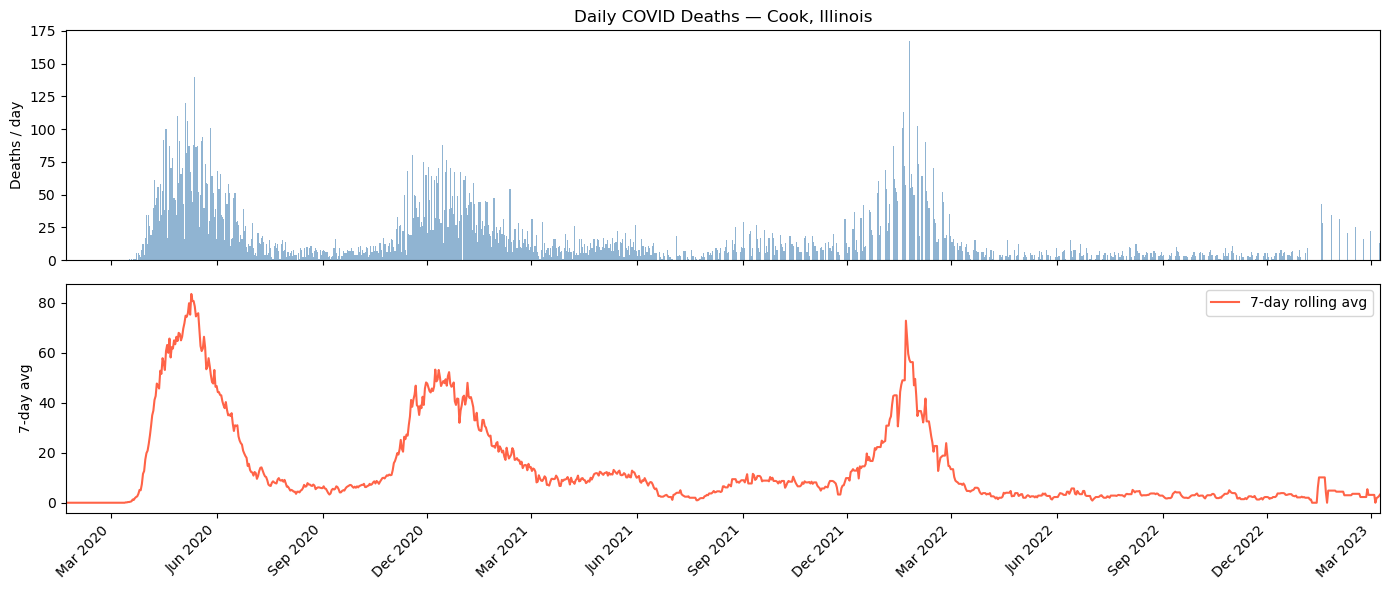

In [11]:
# Final selection
PICK_COUNTY = 'Cook'   # <-- set county here

matches = [r for r in records
           if r['state'] == PICK_STATE and r['county'] == PICK_COUNTY]

if len(matches) == 0:
    raise ValueError(f'No match: {PICK_STATE} / {PICK_COUNTY}\nAvailable counties: {counties}')
if len(matches) > 1:
    print(f'WARNING: {len(matches)} rows matched — using first')

selected   = matches[0]
raw_deaths = selected['daily']          # daily new deaths (float32 array)
cumul      = selected['cumulative']     # for reference

print(f'Selected:      {selected["label"]}')
print(f'Date range:    {dates[0].date()} → {dates[-1].date()} ({n_days} days)')
print(f'Total deaths:  {int(cumul[-1]):,}')
print(f'Peak day:      {int(raw_deaths.max())} deaths on {dates[int(raw_deaths.argmax())].date()}')
print(f'Days with >0:  {int((raw_deaths > 0).sum())}')

# Plot
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].bar(dates, raw_deaths, color='steelblue', alpha=0.6, width=1)
axes[0].set_title(f'Daily COVID Deaths — {selected["label"]}', fontsize=12)
axes[0].set_ylabel('Deaths / day')

rolling = pd.Series(raw_deaths).rolling(7, center=True, min_periods=1).mean()
axes[1].plot(dates, rolling, color='tomato', linewidth=1.5, label='7-day rolling avg')
axes[1].set_ylabel('7-day avg')
axes[1].legend()

for ax in axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax.set_xlim(dates[0], dates[-1])

plt.tight_layout()
plt.show()

## 6. Preprocess — Smooth & Scale

In [12]:
# 7-day rolling average removes weekend reporting artifacts
smoothed = pd.Series(raw_deaths).rolling(7, min_periods=1, center=True).mean().values.astype(np.float32)
smoothed = np.clip(smoothed, 0, None)

scaler = MinMaxScaler(feature_range=(0, 1))
scaled = scaler.fit_transform(smoothed.reshape(-1, 1)).flatten()

print(f'Smoothed — min: {smoothed.min():.2f}, max: {smoothed.max():.2f}, mean: {smoothed.mean():.2f}')
print(f'Scaled   — min: {scaled.min():.4f}, max: {scaled.max():.4f}')

Smoothed — min: 0.00, max: 83.57, mean: 13.39
Scaled   — min: 0.0000, max: 1.0000


## 7. Dataset — Sliding Window

In [13]:
class TimeSeriesDataset(Dataset):
    def __init__(self, series, seq_len, forecast_len):
        self.series = series
        self.seq_len = seq_len
        self.forecast_len = forecast_len

    def __len__(self):
        return max(0, len(self.series) - self.seq_len - self.forecast_len)

    def __getitem__(self, idx):
        x = self.series[idx : idx + self.seq_len]
        y = self.series[idx + self.seq_len : idx + self.seq_len + self.forecast_len]
        return (
            torch.tensor(x, dtype=torch.float32).unsqueeze(-1),
            torch.tensor(y, dtype=torch.float32)
        )

split      = int(len(scaled) * 0.8)
split_date = dates[split]
train_ds   = TimeSeriesDataset(scaled[:split], SEQ_LEN, FORECAST_LEN)
val_ds     = TimeSeriesDataset(scaled[split:], SEQ_LEN, FORECAST_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

print(f'Train: days 0–{split} (up to {split_date.date()}) → {len(train_ds)} windows')
print(f'Val:   days {split}–{n_days} → {len(val_ds)} windows')
if len(val_ds) == 0:
    print('WARNING: Val set empty. Try reducing SEQ_LEN or FORECAST_LEN.')

Train: days 0–914 (up to 2022-07-24) → 764 windows
Val:   days 914–1143 → 79 windows


## 8. LSTM Model

In [14]:
class LSTMForecaster(nn.Module):
    def __init__(self, input_size=1, hidden_size=128, num_layers=2,
                 dropout=0.2, forecast_len=90):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_size, forecast_len)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(self.dropout(out[:, -1]))

model = LSTMForecaster(
    input_size=1, hidden_size=128, num_layers=2,
    dropout=0.2, forecast_len=FORECAST_LEN
).to(device)

print(model)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

LSTMForecaster(
  (lstm): LSTM(1, 128, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=128, out_features=90, bias=True)
)
Parameters: 210,778


## 9. Training

Epoch  10/50 | train=0.01910 | val=0.02709
Epoch  20/50 | train=0.01177 | val=0.06781
Epoch  30/50 | train=0.00803 | val=0.01730
Epoch  40/50 | train=0.00723 | val=0.01000
Epoch  50/50 | train=0.00672 | val=0.00662

Best val loss: 0.00662


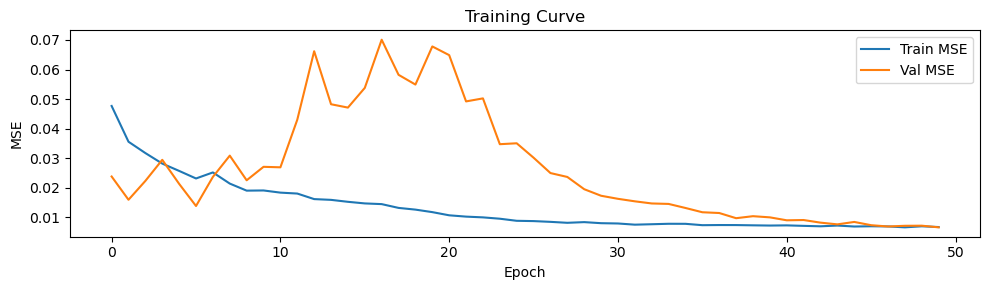

In [16]:
optimizer  = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
criterion  = nn.MSELoss()
scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

train_losses, val_losses = [], []
best_val_loss = float('inf')

for epoch in range(EPOCHS):
    model.train()
    batch_losses = []
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        batch_losses.append(loss.item())

    model.eval()
    val_batch_losses = []
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            val_batch_losses.append(criterion(model(x), y).item())

    train_loss = np.mean(batch_losses)
    val_loss   = np.mean(val_batch_losses) if val_batch_losses else float('nan')
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_covid_model.pt')

    if (epoch + 1) % 10 == 0:
        cur_lr = optimizer.param_groups[0]['lr']
        print(f'Epoch {epoch+1:3d}/{EPOCHS} | train={train_loss:.5f} | val={val_loss:.5f}')

model.load_state_dict(torch.load('best_covid_model.pt', map_location=device))
print(f'\nBest val loss: {best_val_loss:.5f}')

plt.figure(figsize=(10, 3))
plt.plot(train_losses, label='Train MSE')
plt.plot(val_losses,   label='Val MSE')
plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.title('Training Curve')
plt.legend(); plt.tight_layout(); plt.show()

## 10. HuggingFace Pipeline Wrapper

In [17]:
class COVIDForecastPipeline(Pipeline):
    """
    HuggingFace-style pipeline wrapping the LSTM forecaster.
    Input:  raw daily death counts (np.array or list), length >= seq_len
    Output: dict — 'forecast' (floats), 'dates' (strings), 'steps' (int)
    """
    def __init__(self, model, scaler, seq_len, last_known_date, **kwargs):
        self.model           = model
        self.scaler          = scaler
        self.seq_len         = seq_len
        self.last_known_date = pd.Timestamp(last_known_date)
        self._device         = next(model.parameters()).device
        self.model.eval()

    def _sanitize_parameters(self, **kwargs):
        return {}, {}, {}

    def preprocess(self, inputs):
        arr      = np.array(inputs, dtype=np.float32)
        smoothed = pd.Series(arr).rolling(7, min_periods=1, center=True).mean().values
        smoothed = np.clip(smoothed, 0, None)
        window   = smoothed[-self.seq_len:]
        scaled   = self.scaler.transform(window.reshape(-1, 1)).flatten()
        tensor   = torch.tensor(scaled, dtype=torch.float32).unsqueeze(0).unsqueeze(-1)
        return {'input_tensor': tensor.to(self._device)}

    def _forward(self, model_inputs):
        with torch.no_grad():
            output = self.model(model_inputs['input_tensor'])
        return {'output_tensor': output}

    def postprocess(self, model_outputs):
        out         = model_outputs['output_tensor'].cpu().numpy()
        out_unscaled = np.clip(
            self.scaler.inverse_transform(out.reshape(-1, 1)).flatten(), 0, None
        )
        forecast_dates = [
            (self.last_known_date + pd.Timedelta(days=i+1)).strftime('%Y-%m-%d')
            for i in range(len(out_unscaled))
        ]
        return {'forecast': out_unscaled.tolist(), 'dates': forecast_dates, 'steps': len(out_unscaled)}

    def __call__(self, inputs):
        return self.postprocess(self._forward(self.preprocess(inputs)))


forecast_pipeline = COVIDForecastPipeline(
    model=model, scaler=scaler,
    seq_len=SEQ_LEN, last_known_date=dates[-1]
)
print('Pipeline ready.')

Pipeline ready.


## 11. Forecast the Next 90 Days

In [18]:
result = forecast_pipeline(raw_deaths)

forecast_dates  = pd.to_datetime(result['dates'])
forecast_values = np.array(result['forecast'])

print(f'Forecast period: {result["dates"][0]} → {result["dates"][-1]}')
print(f'Peak forecast:   {forecast_values.max():.1f} deaths/day on {result["dates"][int(forecast_values.argmax())]}')
print(f'Total forecast:  {forecast_values.sum():.0f} deaths over 90 days')

Forecast period: 2023-03-10 → 2023-06-07
Peak forecast:   24.0 deaths/day on 2023-05-20
Total forecast:  1073 deaths over 90 days


## 12. Visualize

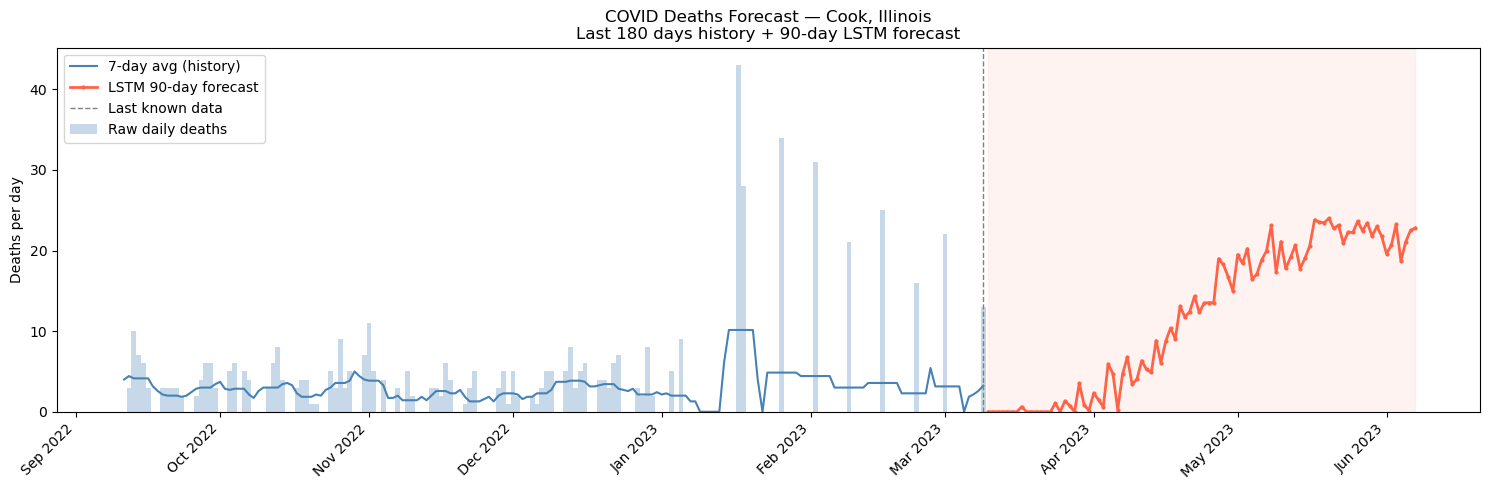

In [19]:
HISTORY_DAYS = 180

hist_dates  = dates[-HISTORY_DAYS:]
hist_raw    = raw_deaths[-HISTORY_DAYS:]
hist_smooth = pd.Series(raw_deaths).rolling(7, min_periods=1, center=True).mean().values[-HISTORY_DAYS:]

fig, ax = plt.subplots(figsize=(15, 5))
ax.bar(hist_dates,     hist_raw,       color='steelblue', alpha=0.3, width=1, label='Raw daily deaths')
ax.plot(hist_dates,    hist_smooth,    color='steelblue', linewidth=1.5,      label='7-day avg (history)')
ax.plot(forecast_dates, forecast_values, color='tomato', linewidth=2,
        marker='o', markersize=2,                                              label='LSTM 90-day forecast')
ax.axvspan(forecast_dates[0], forecast_dates[-1], alpha=0.07, color='tomato')
ax.axvline(x=dates[-1], color='gray', linestyle='--', linewidth=1,            label='Last known data')
ax.set_title(f'COVID Deaths Forecast — {selected["label"]}\n'
             f'Last {HISTORY_DAYS} days history + 90-day LSTM forecast', fontsize=12)
ax.set_ylabel('Deaths per day')
ax.set_ylim(bottom=0)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

## 13. Evaluate on Validation Set

Validation metrics (in original deaths/day units):
  MAE:  5.47 deaths/day
  RMSE: 6.56 deaths/day


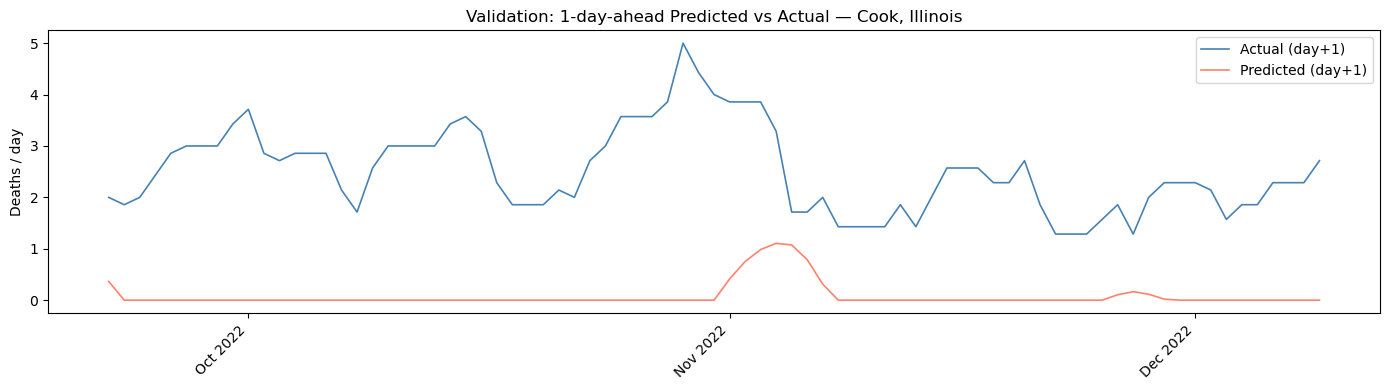

In [20]:
model.eval()
all_preds, all_actuals = [], []

with torch.no_grad():
    for x, y in val_loader:
        x = x.to(device)
        all_preds.append(model(x).cpu().numpy())
        all_actuals.append(y.numpy())

if all_preds:
    all_preds   = np.concatenate(all_preds,   axis=0)
    all_actuals = np.concatenate(all_actuals, axis=0)

    def inv(arr):
        return np.clip(scaler.inverse_transform(arr.reshape(-1, 1)).reshape(arr.shape), 0, None)

    preds_raw   = inv(all_preds)
    actuals_raw = inv(all_actuals)

    mae  = np.mean(np.abs(preds_raw - actuals_raw))
    rmse = np.sqrt(np.mean((preds_raw - actuals_raw)**2))
    print(f'Validation metrics (in original deaths/day units):')
    print(f'  MAE:  {mae:.2f} deaths/day')
    print(f'  RMSE: {rmse:.2f} deaths/day')

    val_dates = dates[split + SEQ_LEN : split + SEQ_LEN + len(preds_raw)]
    plt.figure(figsize=(14, 4))
    plt.plot(val_dates, actuals_raw[:, 0], label='Actual (day+1)',    color='steelblue', linewidth=1.2)
    plt.plot(val_dates, preds_raw[:, 0],   label='Predicted (day+1)', color='tomato',    linewidth=1.2, alpha=0.8)
    plt.title(f'Validation: 1-day-ahead Predicted vs Actual — {selected["label"]}')
    plt.ylabel('Deaths / day')
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(plt.gca().xaxis.get_majorticklabels(), rotation=45, ha='right')
    plt.legend(); plt.tight_layout(); plt.show()
else:
    print('Validation set was empty — no evaluation possible.')

## 14. Save & Reload

In [ ]:
torch.save(model.state_dict(), 'covid_lstm_jhu.pt')
with open('covid_scaler_jhu.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print('Saved: covid_lstm_jhu.pt  covid_scaler_jhu.pkl')

# --- Reload template ---
# with open('covid_scaler_jhu.pkl', 'rb') as f:
#     loaded_scaler = pickle.load(f)
# loaded_model = LSTMForecaster(forecast_len=FORECAST_LEN)
# loaded_model.load_state_dict(torch.load('covid_lstm_jhu.pt', map_location='cpu'))
# pipe = COVIDForecastPipeline(loaded_model, loaded_scaler, SEQ_LEN, dates[-1])
# result = pipe(raw_deaths)